## VOL REGIME

In [1]:
import sys
from pathlib import Path

# Repo root: walk up from notebook file (Cursor) and/or kernel cwd
_nb = globals().get("__vsc_ipynb_file__")
ROOT = None
for start in ([Path(_nb)] if _nb else []) + [Path.cwd()]:
    p = start.resolve()
    if p.suffix == ".ipynb":
        p = p.parent
    for candidate in (p, *p.parents):
        if (candidate / "vol_surface.py").is_file():
            ROOT = candidate
            break
    if ROOT is not None:
        break
if ROOT is None:
    raise FileNotFoundError(
        "Open the Signal_Monitor folder in Cursor, then re-run. "
        f"Could not find vol_surface.py from notebook={_nb!r} cwd={Path.cwd()!r}"
    )
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from volatility_regime import HMMVolatilityRegime

spx_model = HMMVolatilityRegime.from_market("SPX", signal_mode=True)
nsq_model = HMMVolatilityRegime.from_market("NSDQ", signal_mode=True)
dji_model = HMMVolatilityRegime.from_market("DJI", signal_mode=True)

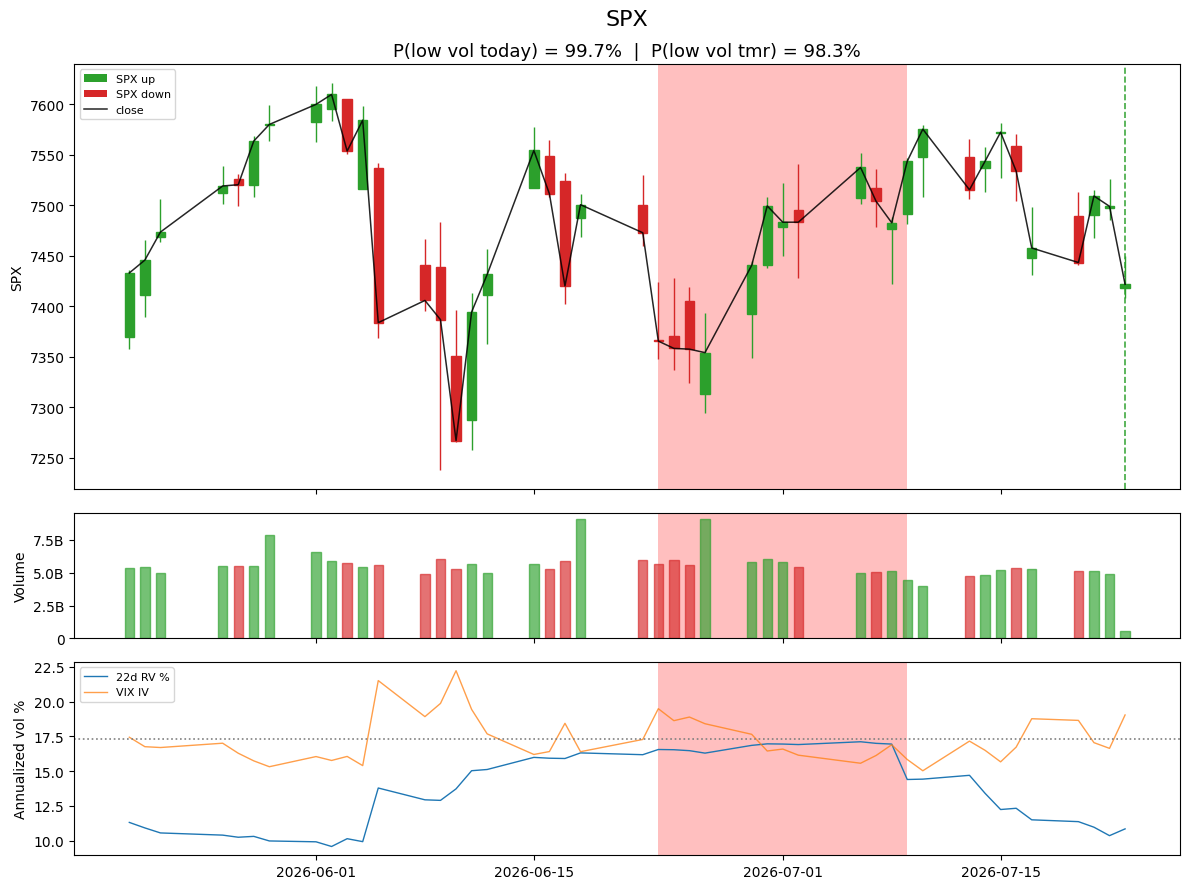


SPX implied vs realized move (1σ)
Spot = 7,424 | IV = 19.0% | 1d hist: avg |move| last 22d
Horizon | Implied   | Historical | Spot ± implied
--------+-----------+------------+---------------
1d      | 89(1.2%)  | 40(0.5%)   | 7,335 | 7,513 
15d     | 345(4.6%) | 183(2.5%)  | 7,079 | 7,768 
22d     | 418(5.6%) | 238(3.2%)  | 7,006 | 7,841 
30d     | 488(6.6%) | 351(4.7%)  | 6,936 | 7,911 


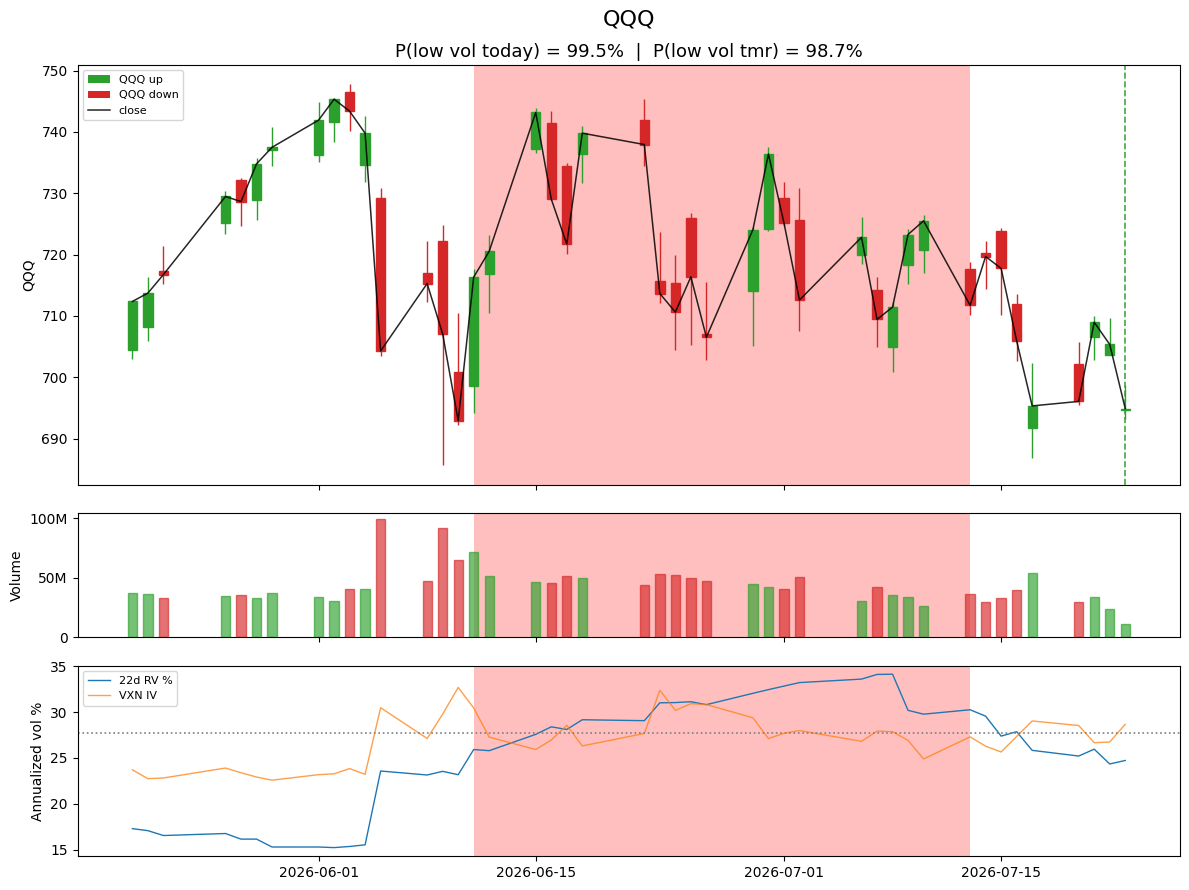


QQQ implied vs realized move (1σ)
Spot = 694.87 | IV = 28.7% | 1d hist: avg |move| last 22d
Horizon | Implied  | Historical | Spot ± implied 
--------+----------+------------+----------------
1d      | 13(1.8%) | 9.3(1.3%)  | 682.32 | 707.42
15d     | 49(7.0%) | 37(5.3%)   | 646.28 | 743.46
22d     | 59(8.5%) | 51(7.3%)   | 636.03 | 753.71
30d     | 69(9.9%) | 66(9.6%)   | 626.16 | 763.58


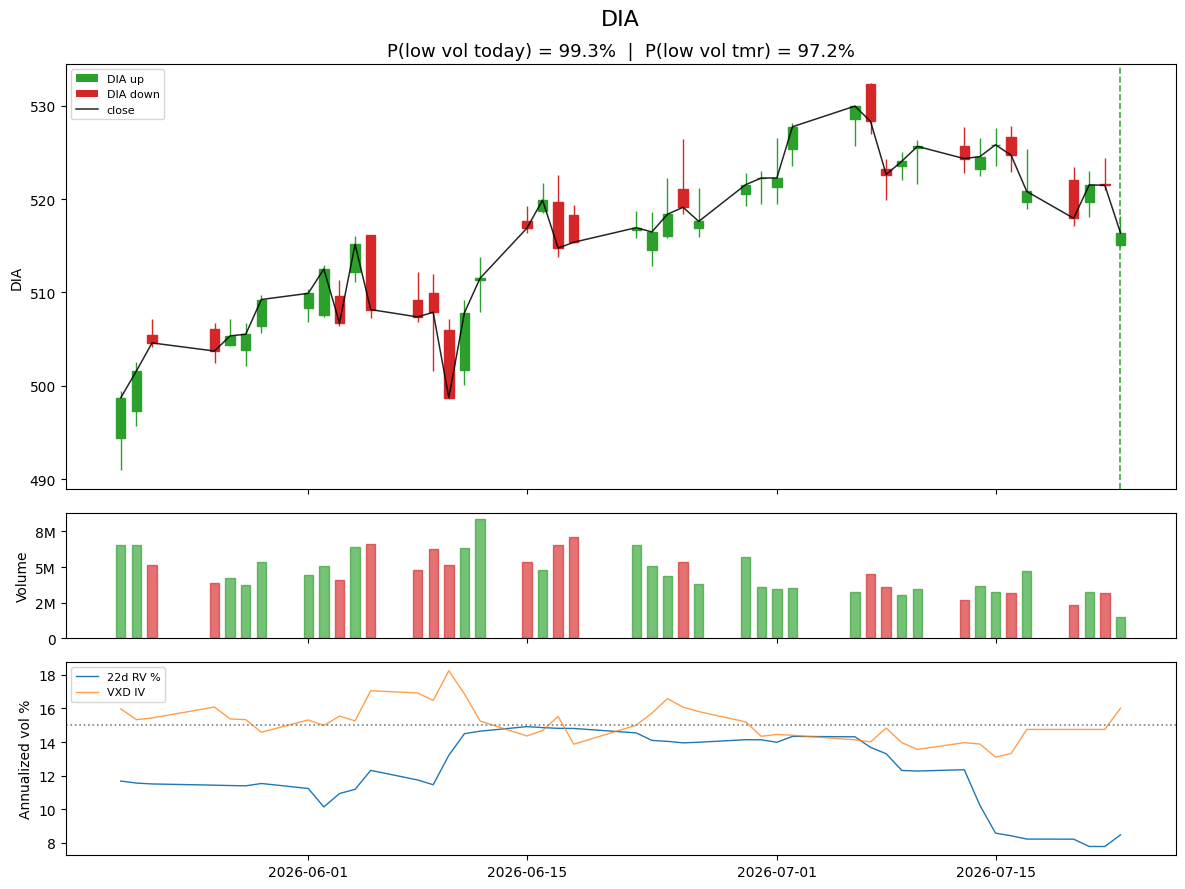


DIA implied vs realized move (1σ)
Spot = 516.37 | IV = 16.0% | 1d hist: avg |move| last 22d
Horizon | Implied   | Historical | Spot ± implied 
--------+-----------+------------+----------------
1d      | 5.2(1.0%) | 2.1(0.4%)  | 511.16 | 521.58
15d     | 20(3.9%)  | 12(2.3%)   | 496.20 | 536.54
22d     | 24(4.7%)  | 13(2.5%)   | 491.94 | 540.80
30d     | 29(5.5%)  | 21(4.0%)   | 487.85 | 544.89


In [2]:
spx_model.display(display_period=44)
nsq_model.display(display_period=44)
dji_model.display(display_period=44)